In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"coffeesales.csv")
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   str    
 1   datetime     3636 non-null   str    
 2   cash_type    3636 non-null   str    
 3   card         3547 non-null   str    
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   str    
dtypes: float64(1), str(5)
memory usage: 405.1 KB


In [4]:
# change 'date' and 'datetime' dtypes
data['date'] = pd.to_datetime(data.date)

In [6]:
data['datetime'] = pd.to_datetime(data.datetime)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3636 non-null   datetime64[us]
 1   datetime     3636 non-null   datetime64[us]
 2   cash_type    3636 non-null   str           
 3   card         3547 non-null   str           
 4   money        3636 non-null   float64       
 5   coffee_name  3636 non-null   str           
dtypes: datetime64[us](2), float64(1), str(3)
memory usage: 287.9 KB


In [8]:
data.isna().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

In [9]:
data.cash_type.unique()

<ArrowStringArray>
['card', 'cash']
Length: 2, dtype: str

In [10]:
data.coffee_name.unique()

<ArrowStringArray>
[              'Latte',       'Hot Chocolate',           'Americano',
 'Americano with Milk',               'Cocoa',             'Cortado',
            'Espresso',          'Cappuccino']
Length: 8, dtype: str

In [11]:
data.groupby('date').size()

date
2024-03-01    11
2024-03-02     7
2024-03-03    10
2024-03-04     4
2024-03-05     9
              ..
2025-03-19    21
2025-03-20    20
2025-03-21    20
2025-03-22    12
2025-03-23     6
Length: 381, dtype: int64

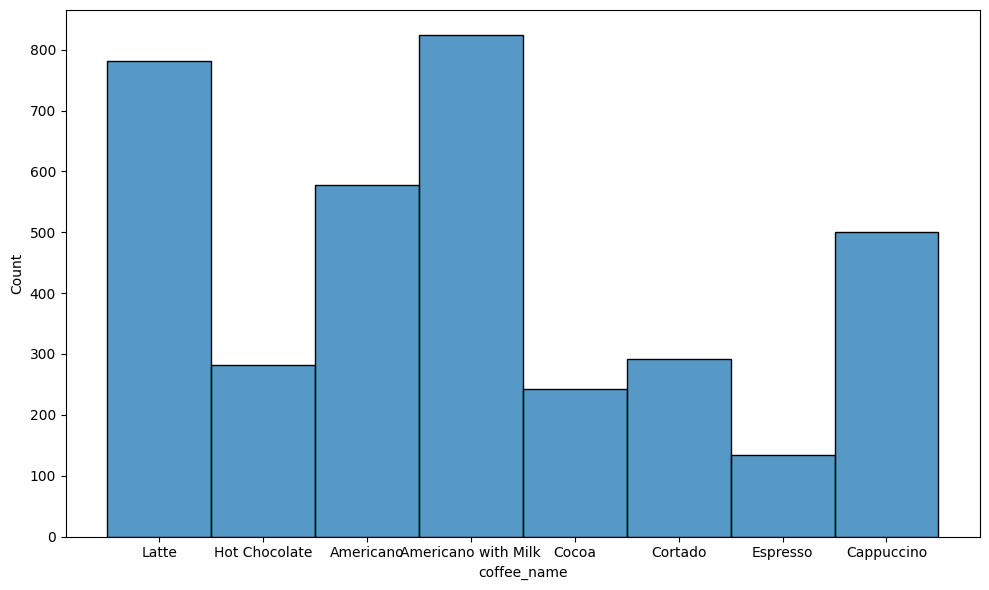

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(x='coffee_name', data=data)
plt.tight_layout()

<Axes: xlabel='coffee_name', ylabel='money'>

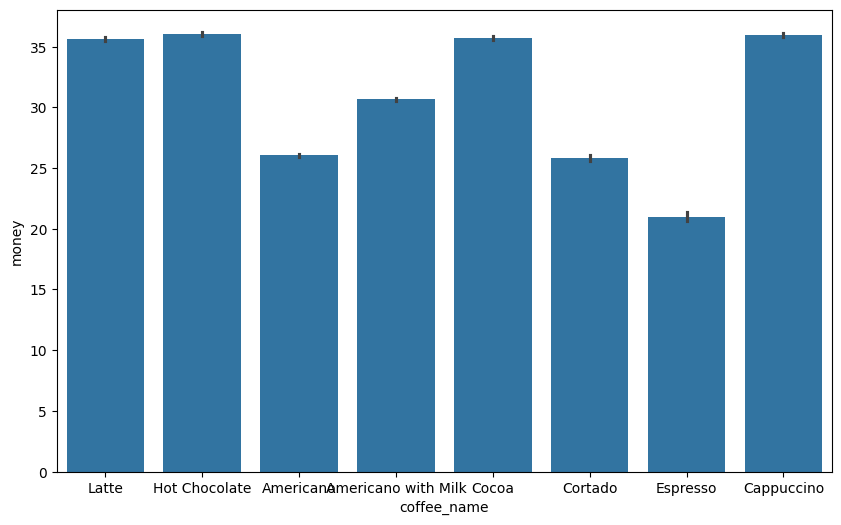

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x='coffee_name',y='money', data=data)

In [17]:
data.head(2)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate


# Working on Coffee_name

In [22]:
coffee_group = data.groupby('coffee_name').size().sort_values(ascending=False)
coffee_group

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
dtype: int64

In [24]:
print("Most popular coffee: ", coffee_group.idxmax())
print('Most number of coffee sales: ', coffee_group.values[0])

Most popular coffee:  Americano with Milk
Most number of coffee sales:  824


In [26]:
print("Least popular coffee: ", coffee_group.idxmin())
print("Least number of coffee sales: ", coffee_group.values[-1])

Least popular coffee:  Espresso
Least number of coffee sales:  134


<Axes: title={'center': 'Coffee Sales'}, xlabel='Coffee name', ylabel='Number of sales'>

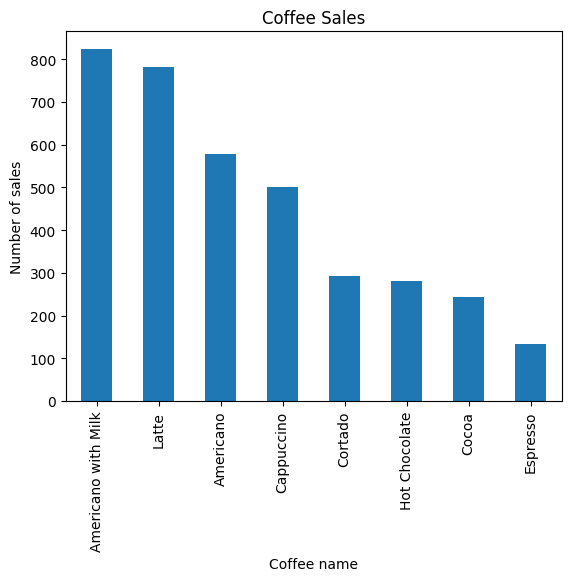

In [28]:
coffee_group.plot(kind='bar', title='Coffee Sales', xlabel='Coffee name', ylabel='Number of sales')

In [33]:
# get percent of coffee sales frequency
total_coffee_sales_qty = coffee_group.values.sum()
percent = ((coffee_group / total_coffee_sales_qty ) * 100).round(2)
percent


coffee_name
Americano with Milk    22.66
Latte                  21.51
Americano              15.90
Cappuccino             13.78
Cortado                 8.03
Hot Chocolate           7.76
Cocoa                   6.68
Espresso                3.69
dtype: float64

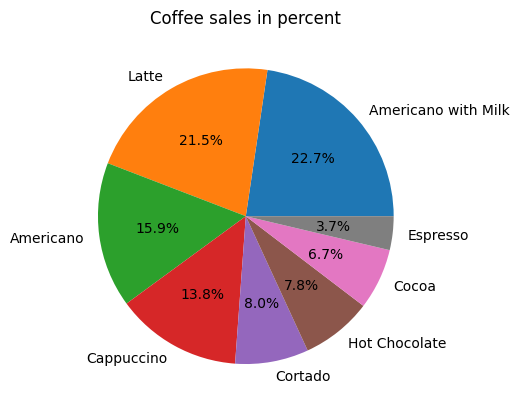

In [35]:
plt.pie(percent, labels=percent.index, autopct='%1.1f%%')
plt.title("Coffee sales in percent")
plt.show()

In [36]:
# Based on quantity sold: Americano with milk at 22.7 % with highest follwed by latte 21.5% and americano 15.9% , whereas 3.7% for espresso at last

In [37]:
data.head(2)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate


# Revenue analysis

In [39]:
data['money'].agg(['min','max','mean','median','std','sum'])

min           18.120000
max           40.000000
mean          31.746859
median        32.820000
std            4.919926
sum       115431.580000
Name: money, dtype: float64

In [41]:
coffee_revenue = data.groupby('coffee_name')['money'].sum()
coffee_revenue

coffee_name
Americano              15062.26
Americano with Milk    25269.12
Cappuccino             18034.14
Cocoa                   8678.16
Cortado                 7534.86
Espresso                2814.28
Hot Chocolate          10172.46
Latte                  27866.30
Name: money, dtype: float64

In [42]:
print("Coffee with highest reveneu: ", coffee_revenue.idxmax())
print("Highest revenue: ", coffee_revenue.max())

Coffee with highest reveneu:  Latte
Highest revenue:  27866.3


In [43]:
print("Coffee with lowest reveneu: ", coffee_revenue.idxmin())
print("Lowest revenue: ", coffee_revenue.min())

Coffee with lowest reveneu:  Espresso
Lowest revenue:  2814.2799999999997


<Axes: title={'center': 'Coffee revenue'}, xlabel='coffee type', ylabel='revenue'>

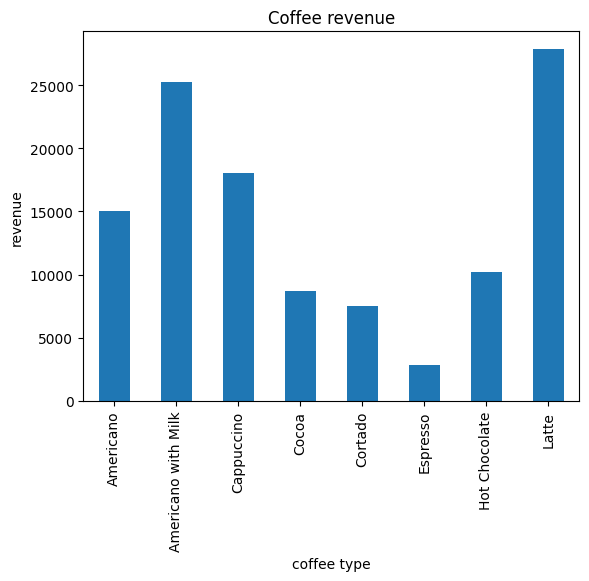

In [46]:
coffee_revenue.plot(kind='bar', title='Coffee revenue', xlabel='coffee type', ylabel='revenue')

In [51]:
coffee_total_revenue = coffee_revenue.values.sum()
revenue_per = ((coffee_revenue / coffee_total_revenue) * 100).round(2)
revenue_per

coffee_name
Americano              13.05
Americano with Milk    21.89
Cappuccino             15.62
Cocoa                   7.52
Cortado                 6.53
Espresso                2.44
Hot Chocolate           8.81
Latte                  24.14
Name: money, dtype: float64

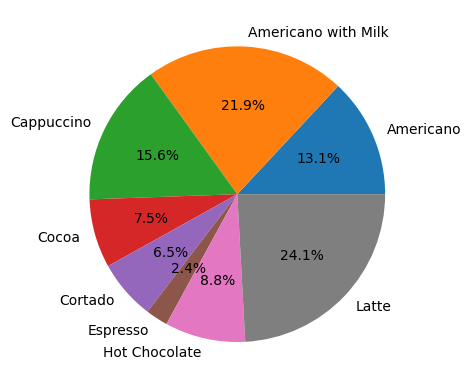

In [66]:
plt.pie(revenue_per, labels=revenue_per.index, autopct='%1.1f%%')
plt.show()

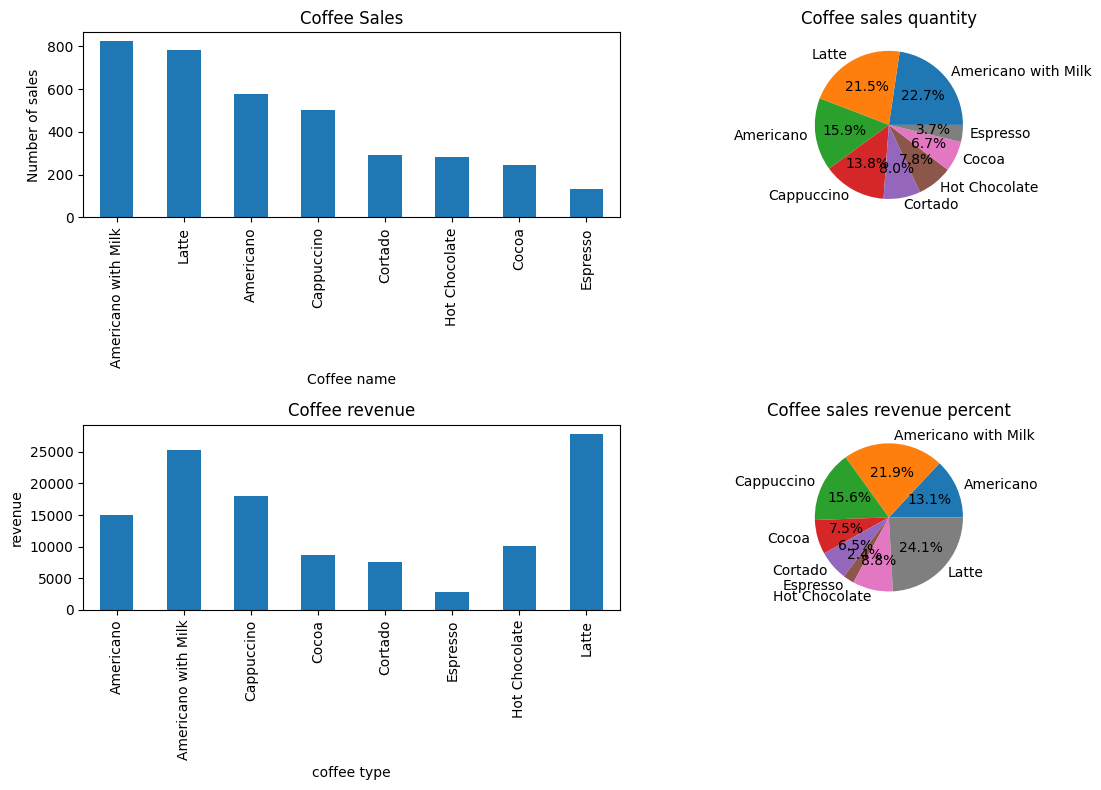

In [67]:
# compare coffee quantity vs revenue
fig, axes = plt.subplots(2,2, figsize=(12,8))
coffee_group.plot(kind='bar', title='Coffee Sales', xlabel='Coffee name', ylabel='Number of sales', ax= axes[0,0])
axes[0,1].pie(percent, labels=percent.index, autopct='%1.1f%%')
axes[0,1].set_title("Coffee sales quantity")
coffee_revenue.plot(kind='bar', title='Coffee revenue', xlabel='coffee type', ylabel='revenue', ax=axes[1,0])
axes[1,1].pie(revenue_per, labels=revenue_per.index,autopct='%1.1f%%')
axes[1,1].set_title("Coffee sales revenue percent")
plt.tight_layout()
plt.show()


In [68]:
# from above plot
# based on quantity sold: Americano with milk at highest with more than 800 and 22.7 % 
# based on sales revenue: Lattee at highest with 24.1 % 

In [69]:
data.head(2)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate


# cash type -- payment type

In [70]:
data.cash_type.unique()

<ArrowStringArray>
['card', 'cash']
Length: 2, dtype: str

In [73]:
cash_type = data.groupby('cash_type').size()
cash_type

cash_type
card    3547
cash      89
dtype: int64

<Axes: xlabel='cash_type'>

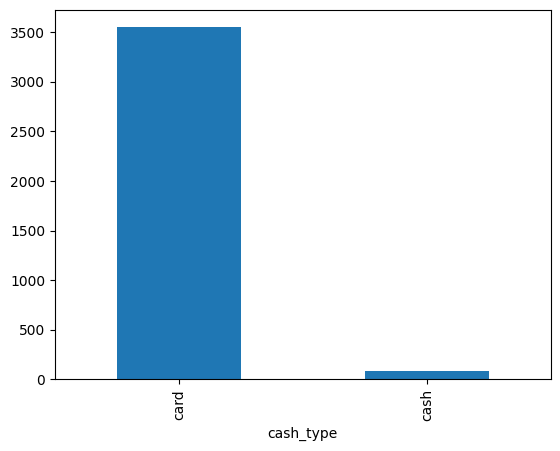

In [74]:
cash_type.plot(kind='bar')

In [76]:
# find revenue by cash type
cash_type_revenue = data.groupby('cash_type')['money'].sum()
cash_type_revenue

cash_type
card    112245.58
cash      3186.00
Name: money, dtype: float64

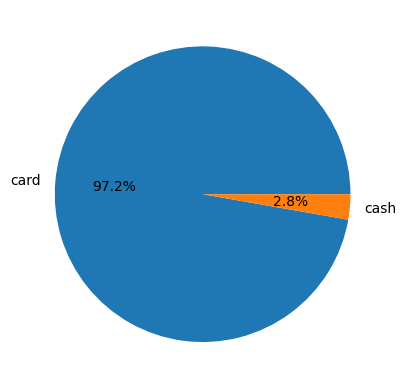

In [79]:
plt.pie(cash_type_revenue, labels=cash_type_revenue.index, autopct='%1.1f%%')
plt.show()

# working with date

In [80]:
data.head(2)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate


In [83]:
# daily revenue
daily_revenue = data.groupby('date')['money'].sum()
daily_revenue

date
2024-03-01    396.30
2024-03-02    228.10
2024-03-03    349.10
2024-03-04    135.20
2024-03-05    338.50
               ...  
2025-03-19    623.56
2025-03-20    597.60
2025-03-21    636.80
2025-03-22    365.42
2025-03-23    204.76
Name: money, Length: 381, dtype: float64

In [82]:
print("start date: ", data.date.min())
print("end date: ", data.date.max())

start date:  2024-03-01 00:00:00
end date:  2025-03-23 00:00:00


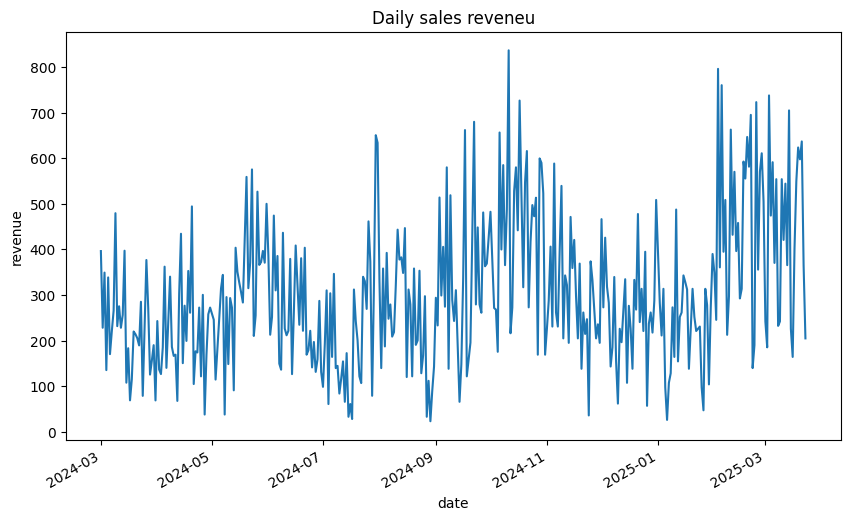

In [86]:
plt.figure(figsize=(10,6))
daily_revenue.plot(kind='line', title="Daily sales reveneu", xlabel='date', ylabel='revenue')
plt.show()

In [87]:
print('Max revenue: ', daily_revenue.max())
print('Min revenue: ', daily_revenue.min())

Max revenue:  836.66
Min revenue:  23.02


In [88]:
daily_revenue.agg(['min','max','mean','sum'])

min         23.020000
max        836.660000
mean       302.970026
sum     115431.580000
Name: money, dtype: float64

In [89]:
print("Highest revenue date: ", daily_revenue.idxmax())
print("Lowest revenue data: ", daily_revenue.idxmin())

Highest revenue date:  2024-10-11 00:00:00
Lowest revenue data:  2024-08-29 00:00:00


In [102]:
# find daily highest revenue and coffee types
daily_sales = data.groupby(['date','coffee_name'])['money'].sum().reset_index()
daily_sales

,date,coffee_name,money
0,2024-03-01,Americano,28.90
1,2024-03-01,Americano with Milk,135.20
2,2024-03-01,Cocoa,38.70
3,2024-03-01,Hot Chocolate,116.10
4,2024-03-01,Latte,77.40
...,...,...,...
1706,2025-03-22,Latte,35.76
1707,2025-03-23,Americano,25.96
1708,2025-03-23,Cappuccino,35.76
1709,2025-03-23,Cocoa,71.52


In [115]:
daily_highest_sales = daily_sales.loc[daily_sales.groupby('date')['money'].idxmax()][['date','coffee_name','money']]
daily_highest_sales

,date,coffee_name,money
1,2024-03-01,Americano with Milk,135.20
6,2024-03-02,Americano with Milk,101.40
13,2024-03-03,Latte,78.70
16,2024-03-04,Latte,77.40
19,2024-03-05,Hot Chocolate,154.80
...,...,...,...
1680,2025-03-19,Americano,207.68
1688,2025-03-20,Americano,207.68
1700,2025-03-21,Latte,214.56
1702,2025-03-22,Americano with Milk,185.16


<Figure size 1500x600 with 0 Axes>

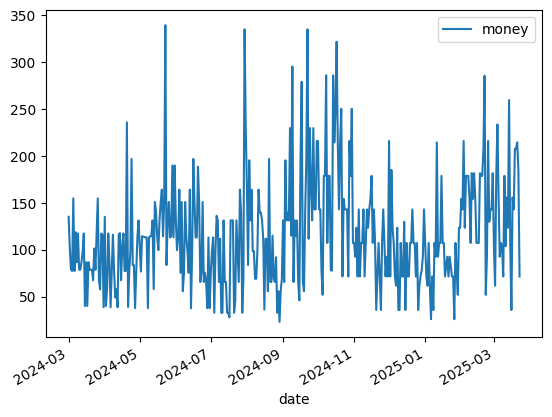

In [128]:
plt.figure(figsize=(15,6))
daily_highest_sales.plot(kind='line', x='date', y='money')
plt.show()

<Axes: title={'center': 'Daily highest coffee revenue'}, xlabel='date', ylabel='money'>

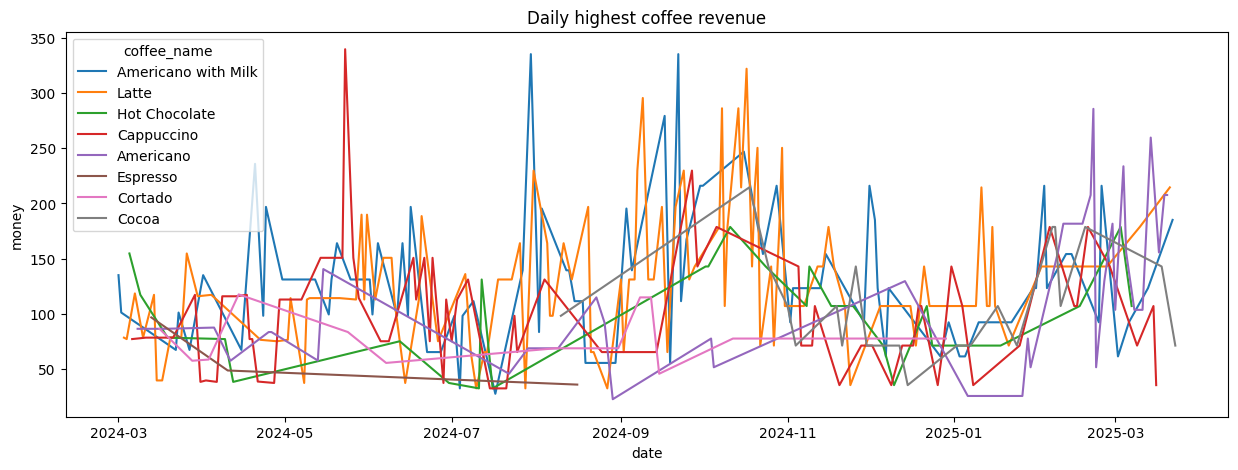

In [132]:
plt.figure(figsize=(15,5))
plt.title("Daily highest coffee revenue")
sns.lineplot(daily_highest_sales, x='date', y='money', hue='coffee_name')


In [133]:
data.head(2)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate


# working with datetime

In [135]:
# get time hour of each transactions
data.datetime.dt.hour

0       10
1       12
2       12
3       13
4       13
        ..
3631    10
3632    14
3633    14
3634    15
3635    18
Name: datetime, Length: 3636, dtype: int32

In [137]:
# group the transcations based on hour i.e find the no of coffee sales base on hour
sales_hour = data.groupby(data['datetime'].dt.hour).size()
sales_hour

datetime
6       5
7      91
8     235
9     247
10    349
11    294
12    249
13    227
14    228
15    245
16    283
17    244
18    220
19    235
20    171
21    197
22    116
dtype: int64

In [139]:
# find the best busssiness hour -- high demand or sales 
print("Bussiness hour or high coffee demand time: ", sales_hour.idxmax())
print("High coffee demand or sales qty: ", sales_hour.max())

Bussiness hour or high coffee demand time:  10
High coffee demand or sales qty:  349


In [140]:
print("Less businss hour: ", sales_hour.idxmin())
print("Less qty sales: ", sales_hour.min())

Less businss hour:  6
Less qty sales:  5


<Axes: title={'center': 'hourly sales distribution'}, xlabel='hour', ylabel='sales'>

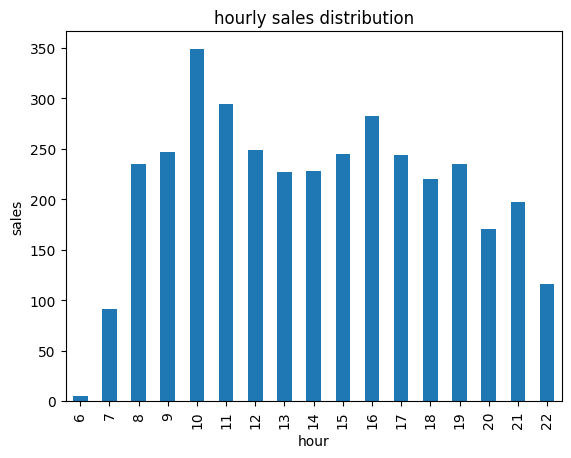

In [183]:
sales_hour.plot(kind='bar', title='hourly sales distribution', xlabel='hour', ylabel='sales')

In [185]:
# hourly revenue
datetime_revenue = data.groupby(data['datetime'].dt.hour)['money'].sum()
datetime_revenue

datetime
6       149.40
7      2940.02
8      7017.88
9      7429.28
10    10994.52
11     8849.10
12     7668.62
13     7108.76
14     7265.80
15     7789.02
16     9221.60
17     7925.00
18     7235.60
19     7966.96
20     5656.92
21     6465.94
22     3747.16
Name: money, dtype: float64

In [187]:
print("Highest revenue time:", datetime_revenue.idxmax())
print("Highest revenue: ", datetime_revenue.max())

Highest revenue time: 10
Highest revenue:  10994.52


In [188]:
print("Lowest revenue time:", datetime_revenue.idxmin())
print("Lowest revenue: ", datetime_revenue.min())

Lowest revenue time: 6
Lowest revenue:  149.4


<Axes: title={'center': 'Hourly revenue distribution'}, xlabel='date', ylabel='revenue'>

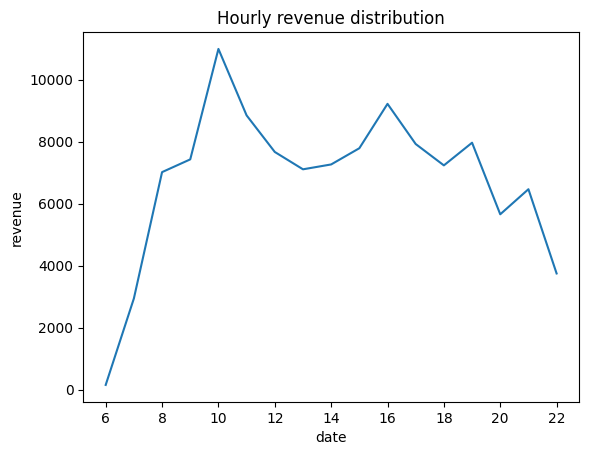

In [190]:
datetime_revenue.plot(kind='line', title='Hourly revenue distribution', xlabel='date', ylabel='revenue')

In [141]:
# divide the time into different category
def time_period(hour):
    if 6 <= hour <=12:
        return 'morning'
    elif 12 < hour <= 17:
        return 'afternoon'
    elif 17 < hour <=20:
        return 'evening'
    else: 
        return 'night'

In [146]:
data['time_period'] = data['datetime'].dt.hour.apply(time_period)
data.head()

,date,datetime,cash_type,card,money,coffee_name,time_period
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,morning
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,morning
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,morning
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,afternoon
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,afternoon


In [147]:
data.groupby('time_period')['money'].sum()

time_period
afternoon    39310.18
evening      20859.48
morning      45048.82
night        10213.10
Name: money, dtype: float64

In [148]:
# highest sales in morning

In [153]:
time_period_group = data.groupby(['time_period','coffee_name'])['money'].sum().reset_index()
time_period_group

,time_period,coffee_name,money
0,afternoon,Americano,5803.48
1,afternoon,Americano with Milk,7390.10
2,afternoon,Cappuccino,6399.66
3,afternoon,Cocoa,2906.00
4,afternoon,Cortado,2160.70
5,afternoon,Espresso,1137.74
6,afternoon,Hot Chocolate,3670.54
7,afternoon,Latte,9841.96
8,evening,Americano,1389.22
9,evening,Americano with Milk,3496.20


<Axes: xlabel='time_period', ylabel='money'>

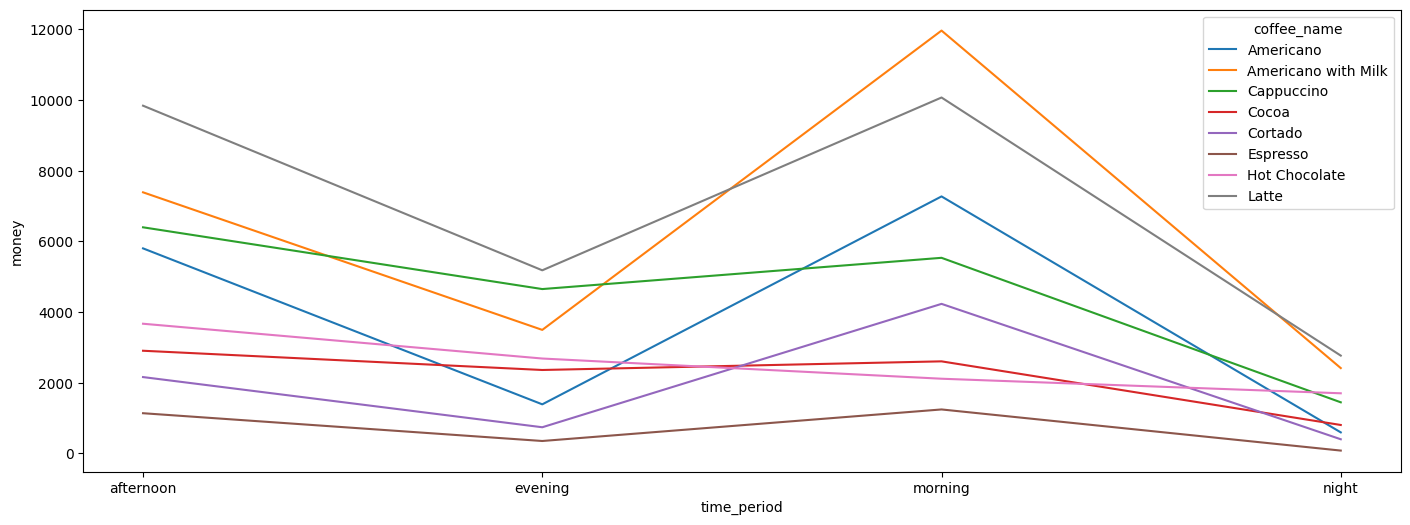

In [157]:
plt.figure(figsize=(17,6))
sns.lineplot(data=time_period_group, x='time_period', y='money', hue='coffee_name')

In [160]:
# find the highest coffee type and revenue from each time period
time_period_group.loc[time_period_group.groupby('time_period')['money'].idxmax()][['time_period','coffee_name','money']]

,time_period,coffee_name,money
7,afternoon,Latte,9841.96
15,evening,Latte,5182.70
17,morning,Americano with Milk,11967.80
31,night,Latte,2768.20


# check Outliers

In [161]:
data.describe()

,date,datetime,money
count,3636,3636,3636.000000
mean,2024-09-30 11:56:02.376237,2024-10-01 02:35:30.535053,31.746859
min,2024-03-01 00:00:00,2024-03-01 10:15:50.520000,18.120000
25%,2024-07-03 00:00:00,2024-07-03 16:54:06.084750,27.920000
50%,2024-10-06 12:00:00,2024-10-07 02:55:12.649500,32.820000
75%,2025-01-08 00:00:00,2025-01-08 07:55:20.299750,35.760000
max,2025-03-23 00:00:00,2025-03-23 18:11:38.635000,40.000000
std,NaN,NaN,4.919926


<Axes: ylabel='money'>

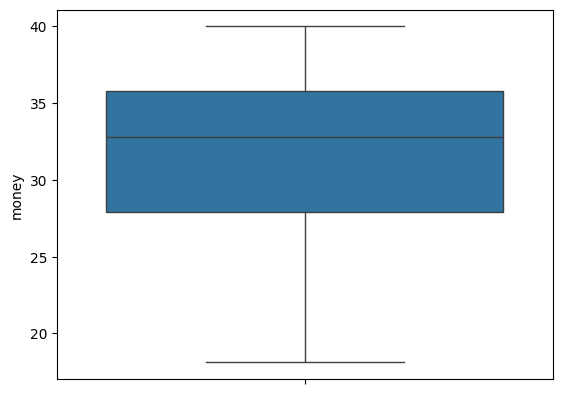

In [162]:
# check outliers in 'money' column using IQR method
sns.boxplot(data=data, y='money')

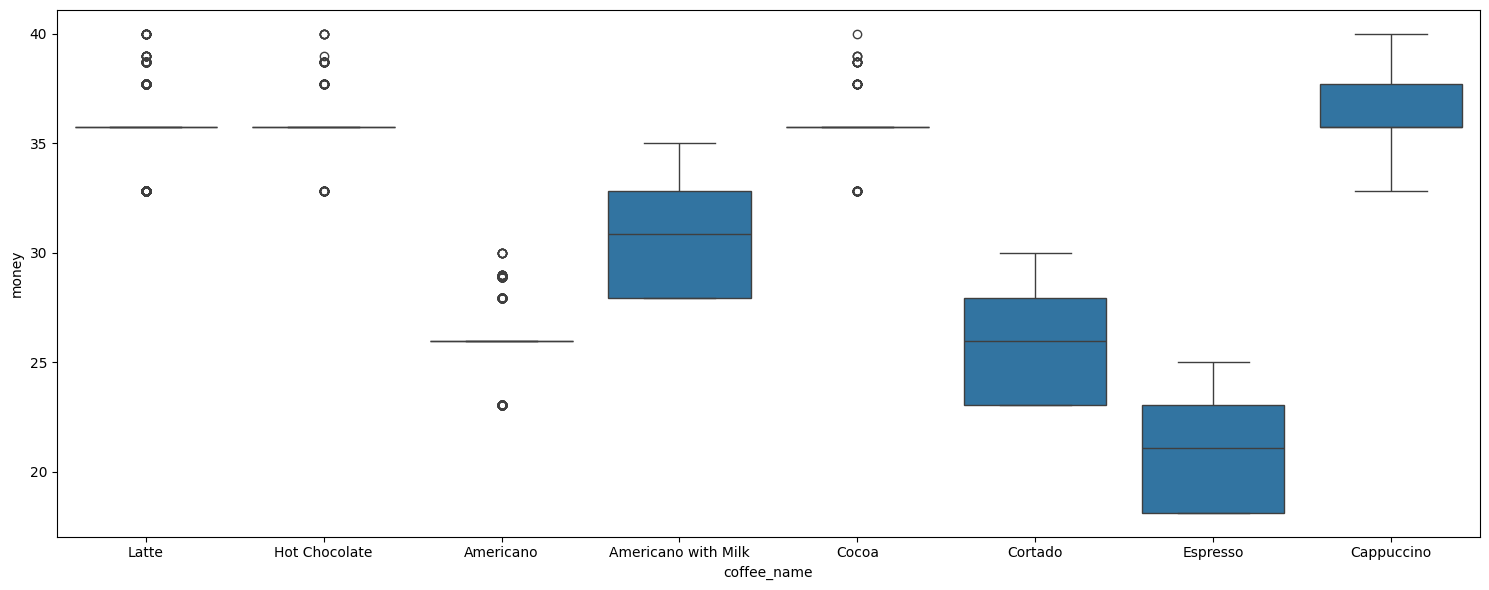

In [165]:
plt.figure(figsize=(15,6))
sns.boxplot(data=data,y='money', x='coffee_name')
plt.tight_layout()

In [166]:
# lets check outliers using IQR method
q1 = data.money.quantile(0.25)
q3 = data.money.quantile(0.75)
iqr = q3 - q1 
print("Quartile 1: ", q1)
print("Quartile 2: ", q3)
print("IQR: ", iqr)

Quartile 1:  27.92
Quartile 2:  35.76
IQR:  7.839999999999996


In [175]:
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print("Lower limit: ", lower_limit)
print("Upper limit: ", upper_limit)

Lower limit:  16.160000000000007
Upper limit:  47.519999999999996


In [179]:
outliers = data[(data.money < lower_limit) | (data.money > upper_limit)]
print("Ouliers : ", outliers.shape[0])

Ouliers :  0


In [180]:
outliers

,date,datetime,cash_type,card,money,coffee_name,time_period


In [181]:
# No outliers exits in 'money' colums